In [1]:
import numpy as np
xf_train = np.load("processed-imgs/xf_train.npy")
xf_test = np.load("processed-imgs/xf_test.npy")
y_train = np.load("processed-imgs/y_train.npy")
y_test = np.load("processed-imgs/y_test.npy")
xi_train = np.load("processed-imgs/xi_train.npy")
xi_test = np.load("processed-imgs/xi_test.npy")
x_train_scaled = np.load("processed-imgs/x_train_scaled.npy")
x_test_scaled = np.load("processed-imgs/x_test_scaled.npy")
x_train_pca = np.load("processed-imgs/x_train_pca.npy")
x_test_pca = np.load("processed-imgs/x_test_pca.npy")   


In [2]:
x_test_pca.shape ,x_train_pca.shape

((2000, 115), (8000, 115))

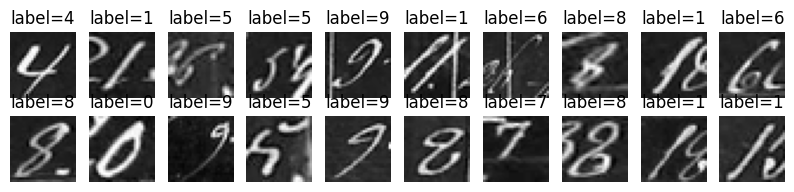

In [3]:
from plot_sample import plot_sample
plot_sample(xi_train, y_train)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score , KFold ,cross_validate
from sklearn.multiclass import OneVsRestClassifier
from time import time
lin_ova= OneVsRestClassifier(LinearRegression())



In [37]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
start = time()
kf_scores=cross_validate(lin_ova, xf_train, y_train, cv=kf, scoring='accuracy',return_train_score=True)
time_lin_ova_kf = time() - start
print(f"KFold Cross-validation train time: {time_lin_ova_kf:.2f} seconds")
print(f"KFold Cross-validation train Accuracy scores: {kf_scores['train_score']}")
print(f"KFold Cross-validation test Accuracy scores: {kf_scores['test_score']}")

KFold Cross-validation train time: 47.83 seconds
KFold Cross-validation train Accuracy scores: [0.81203125 0.80796875 0.81546875 0.81578125 0.818125  ]
KFold Cross-validation test Accuracy scores: [0.64625  0.654375 0.63875  0.644375 0.6275  ]


In [36]:
help(cross_val_score)

Help on function cross_val_score in module sklearn.model_selection._validation:

cross_val_score(estimator, X, y=None, *, groups=None, scoring=None, cv=None, n_jobs=None, verbose=0, params=None, pre_dispatch='2*n_jobs', error_score=nan)
    Evaluate a score by cross-validation.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    estimator : estimator object implementing 'fit'
        The object to use to fit the data.

    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        The data to fit. Can be for example a list, or an array.

    y : array-like of shape (n_samples,) or (n_samples, n_outputs),             default=None
        The target variable to try to predict in the case of
        supervised learning.

    groups : array-like of shape (n_samples,), default=None
        Group labels for the samples used while splitting the dataset into
        train/test set. Only used in conjunction with a "Group" :term:`cv`
     

In [42]:
avg_kf_score_lin_ova_train = np.mean(kf_scores['train_score'])
print(f"Average KFold Cross-validation train Accuracy: {avg_kf_score_lin_ova_train:.4f}")
std_kf_score_lin_ova_train = np.std(kf_scores['train_score'])
print(f"Standard Deviation of KFold train  Cross-validation  Accuracy: {std_kf_score_lin_ova_train:.4f}")

avg_kf_score_lin_ova_test = np.mean(kf_scores['test_score'])
print(f"Average KFold Cross-validation test Accuracy: {avg_kf_score_lin_ova_test:.4f}")
std_kf_score_lin_ova_test = np.std(kf_scores['test_score'])
print(f"Standard Deviation of KFold test Cross-validation  Accuracy: {std_kf_score_lin_ova_test:.4f}")

Average KFold Cross-validation train Accuracy: 0.8139
Standard Deviation of KFold train  Cross-validation  Accuracy: 0.0035
Average KFold Cross-validation test Accuracy: 0.6422
Standard Deviation of KFold test Cross-validation  Accuracy: 0.0089


In [8]:
strart =time()
lin_ova.fit(xf_train, y_train)
time_lin_ova_kf += time()-start

In [10]:
y_test_pred = lin_ova.predict(xf_test)
y_train_pred = lin_ova.predict(xf_train)
y_test_pred

array([6, 7, 3, ..., 2, 4, 9], dtype=int64)

In [11]:
print(f"Linear Regressin with OVA Train Accuracy: {lin_ova.score(xf_train, y_train):.4f}")

print(f"Linear Regressin with OVA Test Accuracy: {lin_ova.score(xf_test, y_test):.4f}")

Linear Regressin with OVA Train Accuracy: 0.7977
Linear Regressin with OVA Test Accuracy: 0.6710


In [12]:
from cmetrics import *
accuracy_lin_ova = acc(y_test, y_test_pred)
print(f"Logistic Regression Accuracy: {accuracy_lin_ova:.4f}%")
prec_lin_ova = precision(y_test, y_test_pred)
print(f"Logistic Regression Precision: {prec_lin_ova:.4f}%")
rec_lin_ova = recall(y_test, y_test_pred)
print(f"Logistic Regression Recall: {rec_lin_ova:.4f}%")
f1_score_lin_ova= f1(y_test, y_test_pred)
print(f"Logistic Regression F1 Score: {f1_score_lin_ova:.4f}%")

Logistic Regression Accuracy: 67.1000%
Logistic Regression Precision: 67.0036%
Logistic Regression Recall: 67.1000%
Logistic Regression F1 Score: 66.8983%


In [13]:
import json

metrics = {
    "accuracy": accuracy_lin_ova,
    "precision": prec_lin_ova,
    "recall": rec_lin_ova,
    "f1_score": f1_score_lin_ova,
    "train_time": time_lin_ova_kf
}

with open("experiments/lin_ova.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.72      0.76      0.74       200
           1       0.64      0.74      0.69       200
           2       0.73      0.71      0.72       200
           3       0.70      0.71      0.71       200
           4       0.67      0.69      0.68       200
           5       0.66      0.64      0.65       200
           6       0.70      0.78      0.74       200
           7       0.64      0.58      0.61       200
           8       0.64      0.52      0.57       200
           9       0.59      0.57      0.58       200

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000



In [16]:
cm=conf_matrix(y_test, y_test_pred)
cm

array([[151,   8,   0,   7,   9,   5,   7,   4,   3,   6],
       [  4, 149,   6,   5,   7,   5,   5,  14,   3,   2],
       [  5,   8, 143,   6,   6,   6,   4,   7,   5,  10],
       [  5,   4,   9, 143,   9,   5,   0,   6,   7,  12],
       [  2,  13,   5,   2, 139,   5,  13,   3,  12,   6],
       [ 14,   5,   5,   4,   3, 127,  22,   7,   8,   5],
       [  5,   9,   5,   3,   1,  15, 155,   0,   7,   0],
       [  1,  23,   7,   8,   8,   1,   3, 116,   6,  27],
       [  9,   9,  10,  14,  11,  13,  12,   6, 104,  12],
       [ 14,   5,   5,  12,  16,   9,   0,  17,   7, 115]], dtype=int64)

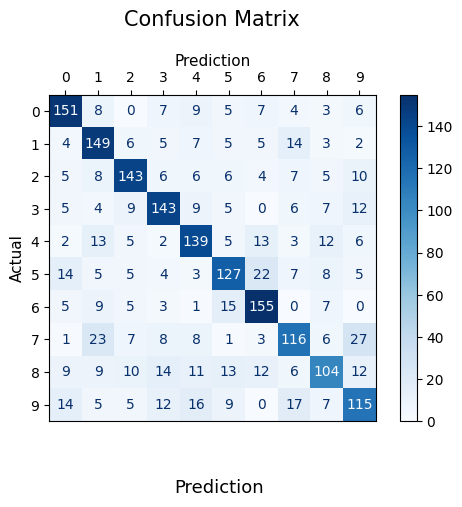

In [17]:
plot_confusion_matrix(cm)

#✔ cross_val_score does NOT fit your model instance
#✔ It makes new cloned models internally using:
clone(log_reg)


#Each fold gets a fresh model, trained only inside cross-validation.

 log_reg_pca instance remains unfitted, so after checks our model generlizain , do:
 log_reg_pca.fit(x_tain_pca , y_train)

In [43]:
from sklearn.model_selection import StratifiedKFold


In [44]:

lin_ova_pca=OneVsRestClassifier(LinearRegression())
skf=StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)
start = time()
skf_scores_pca=cross_validate(lin_ova_pca, x_train_pca, y_train, cv=skf, scoring='accuracy',return_train_score=True)
time_lin_ova_skf_pca = time() - start
print(f"KFold Cross-validation time: {time_lin_ova_skf_pca:.2f} seconds")
print(f"KFold Cross-validation train Accuracy scores: {skf_scores_pca['train_score']}")
print(f"KFold Cross-validation test Accuracy scores: {skf_scores_pca['test_score']}")


KFold Cross-validation time: 5.56 seconds
KFold Cross-validation train Accuracy scores: [0.74953125 0.7496875  0.74265625 0.74859375 0.7440625 ]
KFold Cross-validation test Accuracy scores: [0.705    0.718125 0.728125 0.710625 0.72625 ]


In [45]:
start=time()
lin_ova_pca.fit(x_train_pca, y_train)
time_lin_ova_skf_pca += time()-start

In [48]:
avg_skf_score_lin_ova_pca_train = np.mean(skf_scores_pca['train_score'])
print(f"Average KFold Cross-validation train Accuracy: {avg_skf_score_lin_ova_pca_train:.4f}")
std_skf_score_lin_ova_pca_train = np.std(skf_scores_pca['train_score'])
print(f"Standard Deviation of KFold train  Cross-validation  Accuracy: {std_skf_score_lin_ova_pca_train:.4f}")

avg_skf_score_lin_ova_pca_test = np.mean(skf_scores_pca['test_score'])
print(f"Average KFold Cross-validation test Accuracy: {avg_skf_score_lin_ova_pca_test:.4f}")
std_skf_score_lin_ova_pca_test = np.std(skf_scores_pca['test_score'])
print(f"Standard Deviation of KFold test Cross-validation  Accuracy: {std_skf_score_lin_ova_pca_test:.4f}")

Average KFold Cross-validation train Accuracy: 0.7469
Standard Deviation of KFold train  Cross-validation  Accuracy: 0.0030
Average KFold Cross-validation test Accuracy: 0.7176
Standard Deviation of KFold test Cross-validation  Accuracy: 0.0089


In [23]:
y_test_pred_pca = lin_ova_pca.predict(x_test_pca)
y_train_pred_pca = lin_ova_pca.predict(x_train_pca)
y_test_pred_pca

array([9, 7, 3, ..., 2, 0, 9], dtype=int64)

In [24]:
print(f"Linear Regression with OVA PCA Train Accuracy: {lin_ova_pca.score(x_train_pca, y_train):.4f}")

print(f"Linear Regression with OVAPCA Test Accuracy: {lin_ova_pca.score(x_test_pca, y_test):.4f}")

Linear Regression with OVA PCA Train Accuracy: 0.7432
Linear Regression with OVAPCA Test Accuracy: 0.7340


In [26]:
accuracy_lin_ova_pca = acc(y_test, y_test_pred_pca)
print(f"Linear Regression with OVA PCA Accuracy: {accuracy_lin_ova_pca:.4f}%")
prec_lin_ova_pca = precision(y_test, y_test_pred_pca)
print(f"Linear Regression with OVA PCA Precision: {prec_lin_ova_pca:.4f}%")
rec_lin_ova_pca = recall(y_test, y_test_pred_pca)
print(f"Linear Regression with OVA PCA Recall: {rec_lin_ova_pca:.4f}%")
f1_score_lin_ova_pca = f1(y_test, y_test_pred_pca)
print(f"Linear Regression with OVA PCA F1 Score: {f1_score_lin_ova_pca:.4f}%")

Linear Regression with OVA PCA Accuracy: 73.4000%
Linear Regression with OVA PCA Precision: 73.4685%
Linear Regression with OVA PCA Recall: 73.4000%
Linear Regression with OVA PCA F1 Score: 73.2147%


In [33]:
import json

metrics = {
    "accuracy": accuracy_lin_ova_pca,
    "precision": prec_lin_ova_pca,
    "recall": rec_lin_ova_pca,
    "f1_score": f1_score_lin_ova_pca,
    "train_time": time_lin_ova_skf_pca
}

with open("experiments/lin_ova_pca.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test , y_test_pred_pca))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78       200
           1       0.70      0.78      0.74       200
           2       0.81      0.77      0.78       200
           3       0.73      0.78      0.75       200
           4       0.74      0.75      0.74       200
           5       0.75      0.69      0.72       200
           6       0.76      0.85      0.80       200
           7       0.72      0.67      0.69       200
           8       0.72      0.55      0.62       200
           9       0.66      0.71      0.69       200

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000



In [29]:
cm =conf_matrix(y_test , y_test_pred_pca)
cm

array([[160,   8,   1,   6,   6,   3,   8,   1,   2,   5],
       [  5, 156,   6,   6,   5,   2,   4,  10,   5,   1],
       [  3,   4, 153,   6,   4,   2,   2,   8,   2,  16],
       [  8,   3,   8, 155,   9,   2,   0,   4,   7,   4],
       [  4,  15,   2,   1, 150,   3,  10,   4,   5,   6],
       [  8,   6,   1,   6,   3, 138,  18,   6,   8,   6],
       [  0,  11,   4,   1,   1,  11, 170,   0,   2,   0],
       [  2,  12,   5,   3,   4,   3,   2, 134,   8,  27],
       [  9,   6,   4,  17,   9,  18,  11,   8, 109,   9],
       [ 10,   2,   6,  10,  12,   2,   0,  12,   3, 143]], dtype=int64)

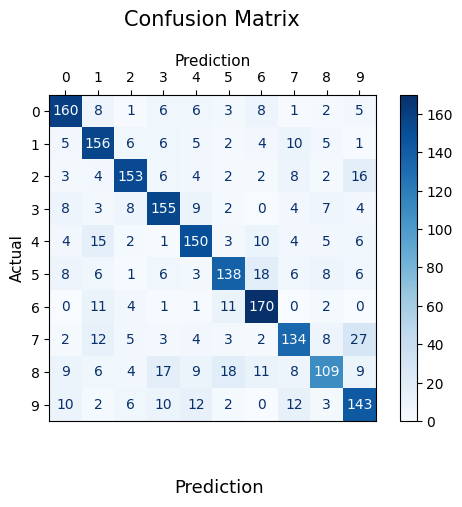

In [30]:
plot_confusion_matrix(cm)